# Agent Distributions

JuPedSim provides `jps.distributions` to **place agents** inside a polygon without
overlaps.  Two strategies are available:

| Function | Control |
|---|---|
| `distribute_by_number` | exact agent count |
| `distribute_by_density` | target density (agents / m²) |

Both accept a `seed` for **reproducible layouts** — same seed → identical positions
every time.  This notebook also shows how to read agent state from a running simulation.

See also: [Getting started](00_getting_started.ipynb) · [Models](02_models.ipynb)

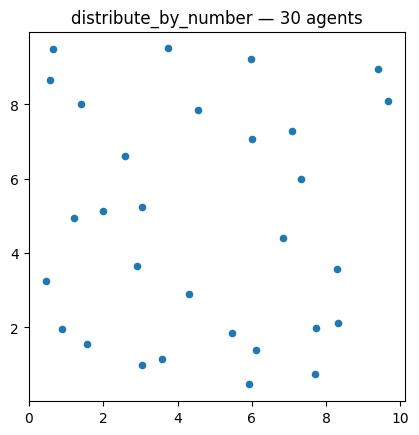

Placed 30 agents.


In [1]:
import jupedsim as jps
import matplotlib.pyplot as plt
import shapely

spawn_area = shapely.Polygon([(0, 0), (10, 0), (10, 10), (0, 10)])

positions_n = jps.distributions.distribute_by_number(
    polygon=spawn_area,
    number_of_agents=30,
    distance_to_agents=0.5,
    distance_to_polygon=0.3,
    seed=42,
)

xs, ys = zip(*positions_n)
fig, ax = plt.subplots()
ax.scatter(xs, ys, s=20)
ax.set_aspect("equal")
ax.set_title(f"distribute_by_number — {len(positions_n)} agents")
plt.show()
print(f"Placed {len(positions_n)} agents.")

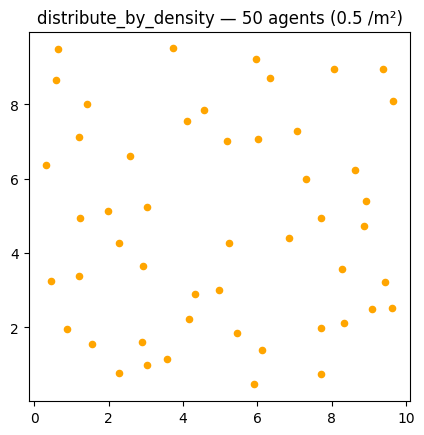

Placed 50 agents.


In [2]:
positions_d = jps.distributions.distribute_by_density(
    polygon=spawn_area,
    density=0.5,           # agents per m²
    distance_to_agents=0.5,
    distance_to_polygon=0.3,
    seed=42,
)

xs_d, ys_d = zip(*positions_d) if positions_d else ([], [])
fig, ax = plt.subplots()
ax.scatter(xs_d, ys_d, s=20, color="orange")
ax.set_aspect("equal")
ax.set_title(f"distribute_by_density — {len(positions_d)} agents (0.5 /m²)")
plt.show()
print(f"Placed {len(positions_d)} agents.")

In [3]:
pts1 = jps.distributions.distribute_by_number(
    polygon=spawn_area,
    number_of_agents=20,
    distance_to_agents=0.5,
    distance_to_polygon=0.3,
    seed=7,
)
pts2 = jps.distributions.distribute_by_number(
    polygon=spawn_area,
    number_of_agents=20,
    distance_to_agents=0.5,
    distance_to_polygon=0.3,
    seed=7,
)
assert pts1 == pts2
print("reproducible with a fixed seed")

reproducible with a fixed seed


In [4]:
import pathlib

trajectory_file = pathlib.Path("agents.sqlite")

simulation = jps.Simulation(
    model=jps.CollisionFreeSpeedModel(),
    geometry=shapely.Polygon([(0, 0), (10, 0), (10, 10), (0, 10)]),
    trajectory_writer=jps.SqliteTrajectoryWriter(output_file=trajectory_file),
)

exit_id = simulation.add_exit_stage([(9, 4), (10, 4), (10, 6), (9, 6)])
journey_id = simulation.add_journey(jps.JourneyDescription([exit_id]))

n_agents = 20
positions = jps.distributions.distribute_by_number(
    polygon=shapely.Polygon([(0.5, 0.5), (3, 0.5), (3, 9.5), (0.5, 9.5)]),
    number_of_agents=n_agents,
    distance_to_agents=0.4,
    distance_to_polygon=0.2,
    seed=1,
)
for position in positions:
    simulation.add_agent(
        jps.CollisionFreeSpeedModelAgentParameters(
            journey_id=journey_id,
            stage_id=exit_id,
            position=position,
            radius=0.12,
        )
    )

simulation.iterate(50)
first = next(iter(simulation.agents()))
print("agent", first.id, "is at", first.position)

while simulation.agent_count() > 0 and simulation.iteration_count() < 10_000:
    simulation.iterate()

print(
    f"Evacuated {n_agents} agents in {simulation.iteration_count()} iterations "
    f"({simulation.elapsed_time():.1f} s)."
)

agent 1 is at (1.7410201066134887, 6.899782095388797)
Evacuated 20 agents in 963 iterations (9.6 s).


In [5]:
from jupedsim.internal.notebook_utils import animate, read_sqlite_file

trajectory_data, walkable_area = read_sqlite_file(trajectory_file)
animate(trajectory_data, walkable_area)

## Try one change

Change the `seed` value in any `distribute_by_number` or `distribute_by_density` call
(e.g. `seed=99`) and re-run the cell.  The agent positions will be different, but still
valid (no overlaps, inside the polygon).  Using `seed=None` gives a random layout on
every run.

## See also

- [Getting started](00_getting_started.ipynb) — minimal simulation from scratch.
- [Models](02_models.ipynb) — choosing and configuring operational models.